# Chemometric Analysis for Food Fraud Detection
## FBMFOR — MSc Food Technology and Quality Assurance

This notebook introduces the key chemometric methods used in food authentication
and fraud detection:

| Method | Type | Purpose |
|--------|------|---------|
| **PCA** | Unsupervised | Explore natural groupings; no class labels used |
| **HCA** | Unsupervised | Visualise sample similarity as a dendrogram |
| **PLS-DA** | Supervised | Classify samples using class labels |
| **OPLS-DA** | Supervised | Separate class-predictive from noise variation |

All methods are illustrated on a **simulated spectral dataset** that mimics the
kind of NMR or FTIR fingerprint data collected in food authentication studies.
The simulated data has known ground-truth class structure, making it ideal for
understanding what each method should — and should not — reveal.

## 0 · Setup

In [1]:
# All packages are pre-installed in Google Colab and standard scientific Python
# environments (conda / pip).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.patches import Ellipse

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from scipy.stats import chi2

from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
%matplotlib inline

plt.rcParams.update({
    'figure.dpi'     : 120,
    'savefig.dpi'    : 150,
    'font.size'      : 11,
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'legend.fontsize': 9,
})

print('Imports OK ✓')

Imports OK ✓


## 1 · Simulated Spectral Dataset

### Why simulated data?

When learning a new analytical method it is invaluable to use data where the
**ground truth is known** — you can then verify whether the method recovers what
you built in. Real experimental data carries unknowns (biological variation,
instrument drift, sample preparation differences) that make it hard to judge
whether a result is genuine or an artefact.

### Dataset design

We simulate 45 one-dimensional spectra with 80 variables (bins) — think of
these as NMR chemical-shift bins or FTIR wavenumber windows.

There are **three classes** representing an idealised food fraud scenario:

| Class | Label | Description |
|-------|-------|-------------|
| 0 | **Authentic** | Genuine product; characteristic sugar profile |
| 1 | **Adulterated — Type A** | High-fructose syrup addition; marker peak at bin ~28 |
| 2 | **Adulterated — Type B** | Rice/invert syrup addition; marker peak at bin ~60 |

Each class shares a background sugar signal (bins 12 and 38) but has unique
marker peaks at specific bin positions plus realistic random noise.
This design mimics the kind of spectral differences seen in honey or olive oil
authentication studies.

In [2]:
# -------------------------------------------------------------------------
# Simulated spectral dataset
# -------------------------------------------------------------------------

N_PER_CLASS = 15     # samples per class
N_VARS      = 80     # spectral bins (pseudo-wavenumber or ppm axis)
N_CLASSES   = 3
x = np.arange(N_VARS)

CLASS_NAMES   = ['Authentic', 'Adulterated A', 'Adulterated B']
CLASS_COLOURS = ['#2196F3', '#F44336', '#4CAF50']   # blue, red, green


def gaussian(x, centre, height, width):
    '''Return a Gaussian peak on the x axis.'''
    return height * np.exp(-0.5 * ((x - centre) / width) ** 2)


def make_class_spectrum(x, peak_defs, noise=0.08, sample_variation=0.05):
    '''
    Simulate one spectrum for a given class.

    peak_defs        : list of (centre, height, width) tuples
    noise            : point-to-point spectral noise sigma
    sample_variation : random scaling applied per sample (concentration variation)
    '''
    spectrum = np.zeros(len(x))
    for centre, height, width in peak_defs:
        spectrum += gaussian(x, centre, height, width)
    spectrum *= (1 + np.random.normal(0, sample_variation))   # dilution noise
    spectrum += np.random.normal(0, noise, len(x))             # spectral noise
    return np.clip(spectrum, 0, None)  # intensities cannot be negative


# Peak definitions:
#   bin 12 : shared sugar signal (all classes)
#   bin 38 : secondary sugar signal (all classes, different heights)
#   bin 28 : Type A marker (e.g. HMF from corn-syrup processing)
#   bin 60 : Type B marker (e.g. characteristic of rice/invert syrup)
PEAKS = {
    'Authentic'     : [(12, 2.0, 3), (38, 1.2, 4)],
    'Adulterated A' : [(12, 1.2, 3), (28, 1.5, 4), (38, 0.7, 4)],
    'Adulterated B' : [(12, 1.5, 3), (38, 0.5, 4), (60, 1.8, 3)],
}

X_raw, y, y_names = [], [], []

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    for _ in range(N_PER_CLASS):
        X_raw.append(make_class_spectrum(x, PEAKS[cls_name]))
        y.append(cls_idx)
        y_names.append(cls_name)

X_raw   = np.array(X_raw)   # shape (45, 80)
y       = np.array(y)
y_names = np.array(y_names)

print(f'Data matrix shape : {X_raw.shape}  (samples x spectral bins)')
print(f'Class distribution: {dict(zip(*np.unique(y_names, return_counts=True)))}')

Data matrix shape : (45, 80)  (samples x spectral bins)
Class distribution: {np.str_('Adulterated A'): np.int64(15), np.str_('Adulterated B'): np.int64(15), np.str_('Authentic'): np.int64(15)}


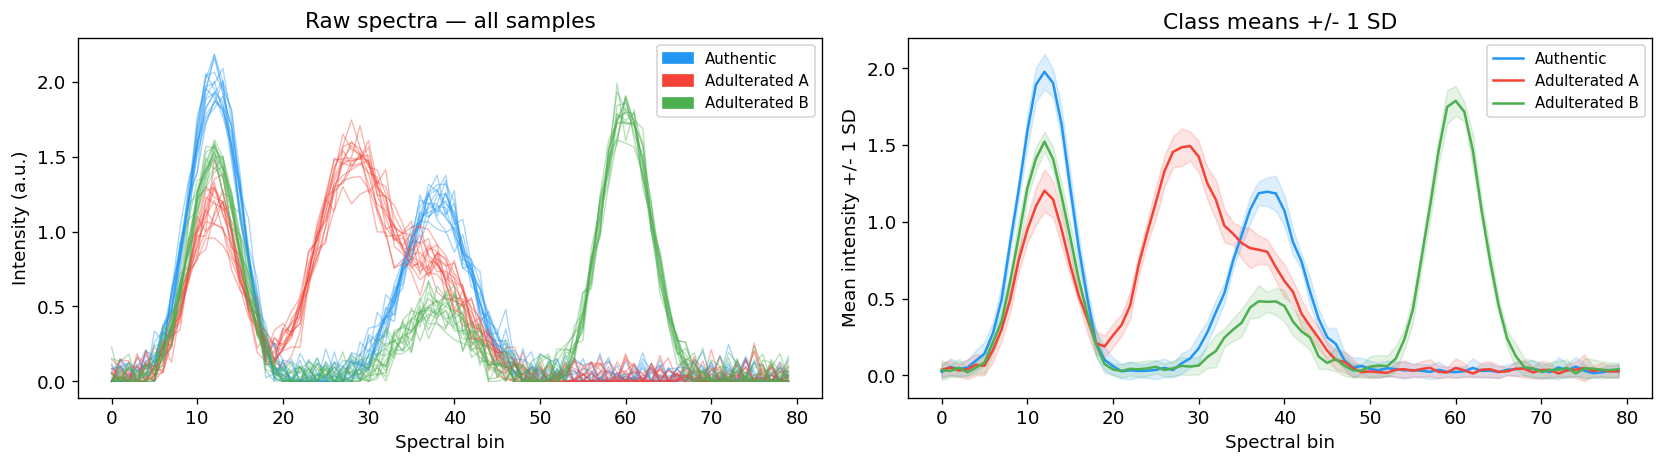

In [3]:
# -------------------------------------------------------------------------
# Figure 1: Raw spectra
# Always inspect the raw data before any analysis.
# -------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: all spectra overlaid
ax = axes[0]
for i in range(len(X_raw)):
    ax.plot(x, X_raw[i], color=CLASS_COLOURS[y[i]], alpha=0.4, linewidth=0.8)
patches = [mpatches.Patch(color=c, label=n)
           for c, n in zip(CLASS_COLOURS, CLASS_NAMES)]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel('Spectral bin')
ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Raw spectra — all samples')

# Right: class mean +/- 1 SD
ax = axes[1]
for cls_idx, (cls_name, col) in enumerate(zip(CLASS_NAMES, CLASS_COLOURS)):
    mask  = y == cls_idx
    mu    = X_raw[mask].mean(axis=0)
    sigma = X_raw[mask].std(axis=0)
    ax.plot(x, mu, color=col, label=cls_name, linewidth=1.5)
    ax.fill_between(x, mu - sigma, mu + sigma, color=col, alpha=0.15)
ax.legend(fontsize=9)
ax.set_xlabel('Spectral bin')
ax.set_ylabel('Mean intensity +/- 1 SD')
ax.set_title('Class means +/- 1 SD')

plt.tight_layout()
plt.show()

## 2 · Preprocessing

Before applying any multivariate method the data matrix must be preprocessed.
The two most important steps are:

### Mean centring

Subtract the **column mean** from every value in that column.
This shifts the origin of the data to the centroid of the dataset, so that
PCA and PLS components describe *departures from the average* rather than
the average itself. Mean centring is almost always applied.

### Variance scaling (UV scaling / autoscaling)

Divide each mean-centred variable by its **standard deviation**.
This gives every variable equal influence regardless of its absolute intensity.

- **When to use**: variables on very different scales, or when you do not want
  intense peaks to dominate simply because they are large.
- **When NOT to use**: when peak height itself is informative. In NMR metabolomics,
  mean centring *without* UV scaling is common so that abundant metabolites
  retain their weight.

For this dataset we apply **mean centring only**, as all variables share the
same intensity scale.

Before centring: column means 0.030 to 1.567
After centring : column means -3.18e-16 to 2.54e-16  (should be ~0)


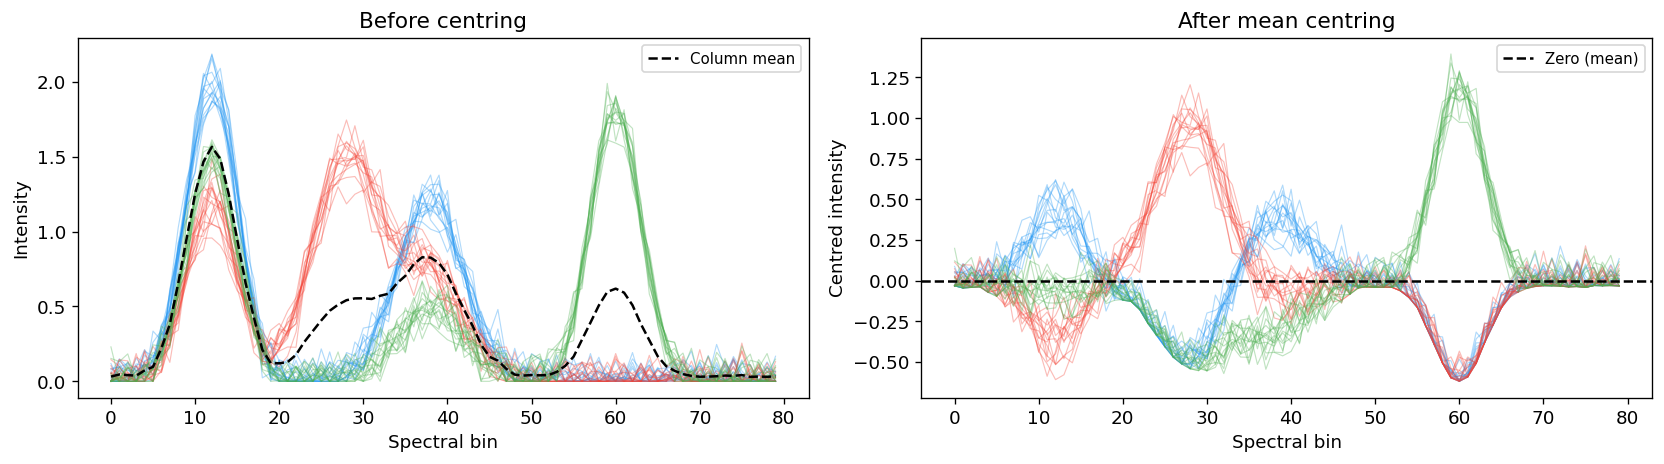

In [4]:
# -------------------------------------------------------------------------
# Preprocessing: mean-centre the data matrix
# -------------------------------------------------------------------------

col_mean = X_raw.mean(axis=0)   # one mean per spectral bin (column)
X        = X_raw - col_mean     # mean-centred matrix, same shape as X_raw

print(f'Before centring: column means {X_raw.mean(axis=0).min():.3f}'
      f' to {X_raw.mean(axis=0).max():.3f}')
print(f'After centring : column means {X.mean(axis=0).min():.2e}'
      f' to {X.mean(axis=0).max():.2e}  (should be ~0)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for i in range(len(X_raw)):
    ax.plot(x, X_raw[i], color=CLASS_COLOURS[y[i]], alpha=0.35, linewidth=0.7)
ax.plot(x, col_mean, 'k--', linewidth=1.5, label='Column mean')
ax.set_title('Before centring')
ax.set_xlabel('Spectral bin')
ax.set_ylabel('Intensity')
ax.legend()

ax = axes[1]
for i in range(len(X)):
    ax.plot(x, X[i], color=CLASS_COLOURS[y[i]], alpha=0.35, linewidth=0.7)
ax.axhline(0, color='k', linewidth=1.5, linestyle='--', label='Zero (mean)')
ax.set_title('After mean centring')
ax.set_xlabel('Spectral bin')
ax.set_ylabel('Centred intensity')
ax.legend()

plt.tight_layout()
plt.show()

## 3 · Principal Component Analysis (PCA)

### What PCA does

PCA finds new axes (principal components, PCs) that point in the directions of
**maximum variance** in the dataset.

- **PC1** captures the most variance (the single most informative direction)
- **PC2** captures the next most, subject to being orthogonal to PC1
- … and so on

Each sample gets a **score** on each PC — its coordinate in the new axis system.
Each spectral bin gets a **loading** on each PC — how strongly it contributes
to that direction.

### Key outputs

| Output | What it shows |
|--------|---------------|
| **Scree plot** | How much variance each PC explains; helps decide how many PCs to retain |
| **Scores plot** | Where each sample sits in PC space — natural groupings? |
| **Loadings plot** | Which spectral bins drive each PC — the chemical interpretation |

### Important: PCA is unsupervised

PCA does **not** use the class labels. If the classes separate in a PCA scores
plot, the spectral differences between classes genuinely dominate the total
variance of the dataset. If they do not separate, either the spectral differences
are subtle, or other variation dominates (instrument drift, concentration, etc.).

Variance explained per PC:
  PC 1:  65.8%  ████████████████████████████████
  PC 2:  29.9%  ██████████████
  PC 3:   0.7%  
  PC 4:   0.3%  
  PC 5:   0.2%  
  PC 6:   0.2%  
  PC 7:   0.2%  
  PC 8:   0.2%  
  PC 9:   0.2%  
  PC10:   0.2%  
  Cumulative (PC1–PC3): 96.4%


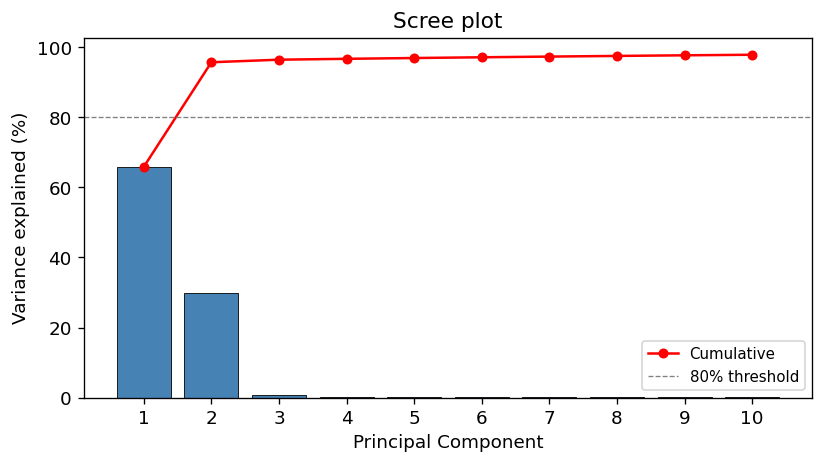

In [5]:
# -------------------------------------------------------------------------
# Fit PCA on the mean-centred data
# -------------------------------------------------------------------------

N_COMPONENTS = 10   # compute 10 PCs; we will plot only the first 2-3

pca    = PCA(n_components=N_COMPONENTS)
scores = pca.fit_transform(X)                   # shape (45, 10)
ev     = pca.explained_variance_ratio_ * 100    # % variance per PC

print('Variance explained per PC:')
for i, v in enumerate(ev):
    bar = '█' * int(v / 2)
    print(f'  PC{i+1:2d}: {v:5.1f}%  {bar}')
print(f'  Cumulative (PC1–PC3): {ev[:3].sum():.1f}%')

# Scree plot: look for an 'elbow' where adding more PCs gives diminishing returns
fig, ax = plt.subplots(figsize=(7, 4))
pcs = np.arange(1, N_COMPONENTS + 1)
ax.bar(pcs, ev, color='steelblue', edgecolor='k', linewidth=0.5)
ax.plot(pcs, np.cumsum(ev), 'ro-', markersize=5, label='Cumulative')
ax.axhline(80, color='grey', linestyle='--', linewidth=0.8, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree plot')
ax.set_xticks(pcs)
ax.legend()
plt.tight_layout()
plt.show()

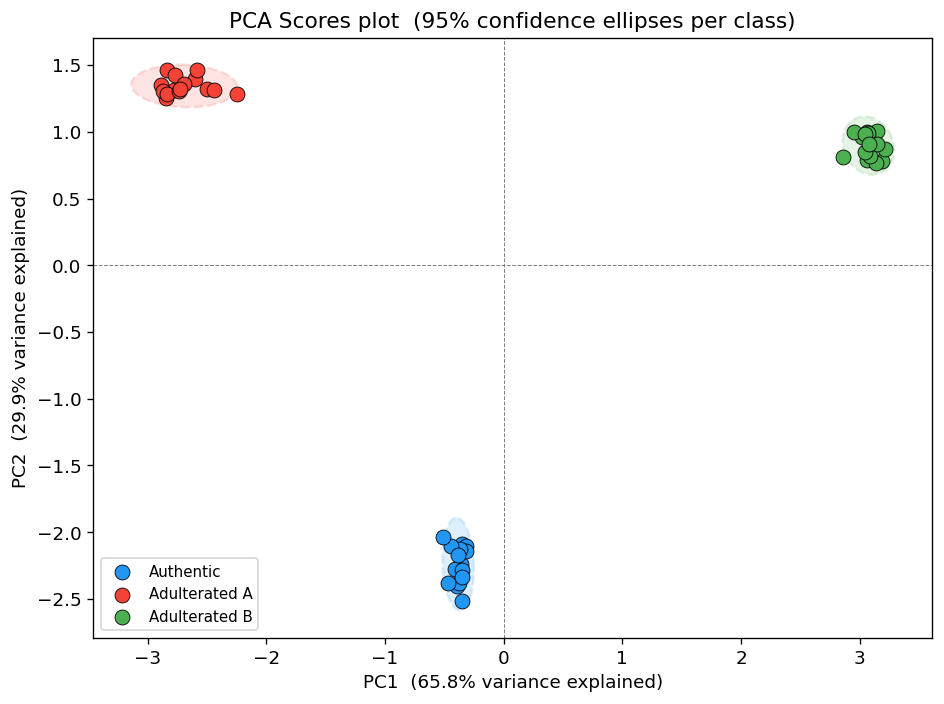

In [6]:
# -------------------------------------------------------------------------
# PCA Scores plot with 95% Hotelling T2 confidence ellipses
#
# The confidence ellipse is the multivariate analogue of a confidence interval.
# It is derived from the chi-squared distribution with 2 degrees of freedom:
# chi2(0.95, 2) ~ 5.991, so the ellipse encloses ~95% of normally distributed
# points from that class.
# -------------------------------------------------------------------------


def confidence_ellipse(scores_2d, ax, colour, confidence=0.95, alpha=0.15):
    '''Draw a confidence ellipse from a 2-column scores array.'''
    cov  = np.cov(scores_2d, rowvar=False)
    mean = scores_2d.mean(axis=0)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order  = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    scale  = np.sqrt(chi2.ppf(confidence, df=2))
    width  = 2 * scale * np.sqrt(eigvals[0])
    height = 2 * scale * np.sqrt(eigvals[1])
    angle  = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    ellipse = Ellipse(mean, width=width, height=height, angle=angle,
                      facecolor=colour, alpha=alpha,
                      edgecolor=colour, linewidth=1.5, linestyle='--')
    ax.add_patch(ellipse)


fig, ax = plt.subplots(figsize=(8, 6))

for cls_idx, (cls_name, col) in enumerate(zip(CLASS_NAMES, CLASS_COLOURS)):
    mask = y == cls_idx
    s2d  = scores[mask, :2]
    confidence_ellipse(s2d, ax, col)
    ax.scatter(s2d[:, 0], s2d[:, 1],
               color=col, edgecolors='k', linewidths=0.5,
               s=80, label=cls_name, zorder=5)

ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--')
ax.set_xlabel(f'PC1  ({ev[0]:.1f}% variance explained)')
ax.set_ylabel(f'PC2  ({ev[1]:.1f}% variance explained)')
ax.set_title('PCA Scores plot  (95% confidence ellipses per class)')
ax.legend()
plt.tight_layout()
plt.show()

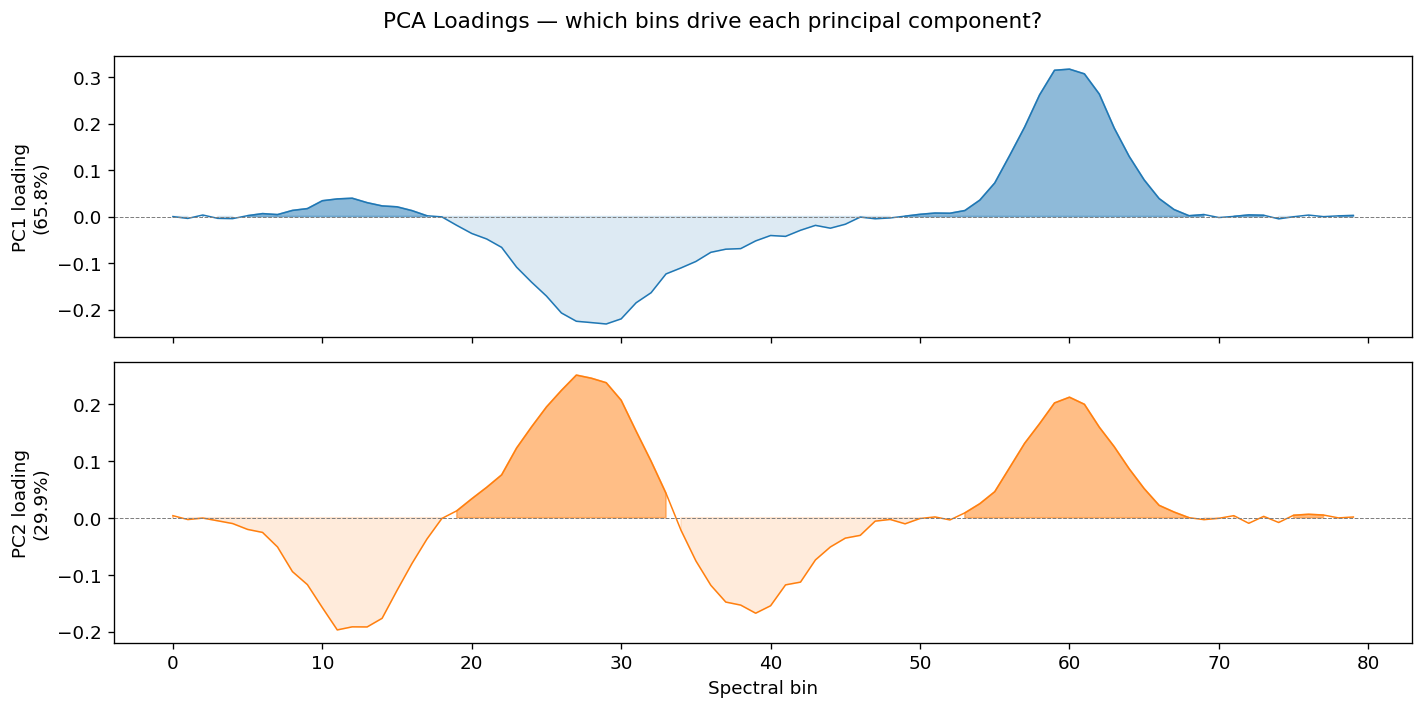

Top 5 bins by absolute loading:
  PC1: bins [60, 59, 61, 62, 58]
  PC2: bins [27, 28, 29, 26, 60]
  (simulated marker peaks at bins 12, 28, 38, 60)


In [7]:
# -------------------------------------------------------------------------
# PCA Loadings plot
#
# Loadings tell us WHICH spectral bins drive each PC.
# A large positive loading at bin X on PC1 means: samples with high intensity
# at bin X have a high (positive) PC1 score.  Comparing the loading profile
# to the known peak positions confirms the chemical meaning of each PC.
# -------------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for pc_idx, ax in enumerate(axes):
    loading = pca.components_[pc_idx]
    ax.fill_between(x, loading, 0,
                    where=(loading >= 0), color=f'C{pc_idx}', alpha=0.5)
    ax.fill_between(x, loading, 0,
                    where=(loading < 0),  color=f'C{pc_idx}', alpha=0.15)
    ax.plot(x, loading, color=f'C{pc_idx}', linewidth=0.9)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_ylabel(f'PC{pc_idx+1} loading\n({ev[pc_idx]:.1f}%)')

axes[-1].set_xlabel('Spectral bin')
fig.suptitle('PCA Loadings — which bins drive each principal component?', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 5 bins by absolute loading:')
for pc_idx in range(2):
    top5 = np.argsort(np.abs(pca.components_[pc_idx]))[::-1][:5]
    print(f'  PC{pc_idx+1}: bins {top5.tolist()}')
print('  (simulated marker peaks at bins 12, 28, 38, 60)')

## 4 · Hierarchical Cluster Analysis (HCA)

HCA is a second unsupervised method that groups samples by pairwise similarity,
producing a **dendrogram** (tree diagram) rather than a scores plot.

### How it works

1. Compute a distance between every pair of samples
2. Merge the two most similar samples into a cluster
3. Recompute distances between all clusters using a **linkage rule**
4. Repeat until all samples belong to one cluster

The height at which two branches merge reflects how different those clusters
are — a short merge = very similar; a tall merge = very different.

### Linkage methods

| Method | Cluster distance | Properties |
|--------|-----------------|------------|
| **Ward** | Increase in total within-cluster variance | Compact, equal-size clusters — most used in metabolomics |
| **Complete** | Maximum distance between members | Avoids elongated clusters |
| **Average** | Average distance between all pairs | Compromise |
| **Single** | Minimum distance between members | Sensitive to outliers |

We use **Ward linkage** with **Euclidean distance** on the mean-centred data.

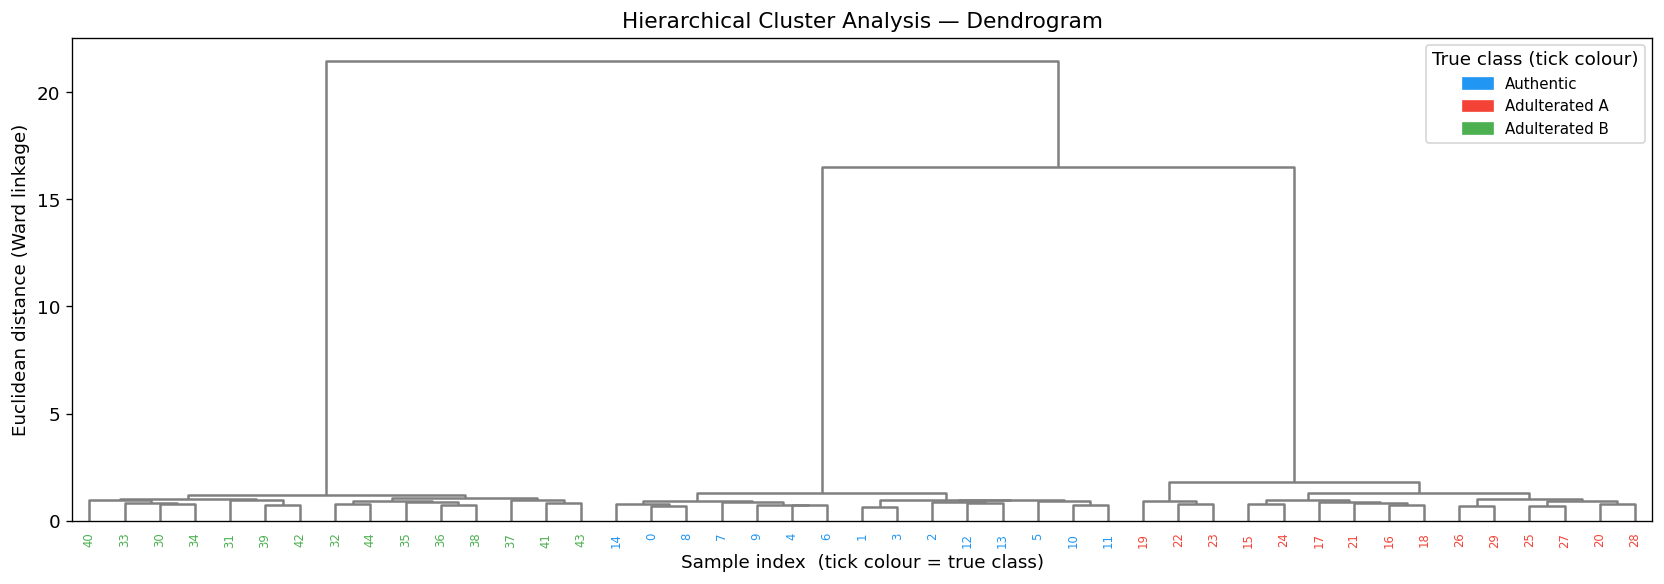

In [8]:
# -------------------------------------------------------------------------
# Hierarchical Cluster Analysis  (Ward linkage, Euclidean distance)
# -------------------------------------------------------------------------

dist_matrix = pdist(X, metric='euclidean')  # pairwise distances
Z           = linkage(dist_matrix, method='ward')  # Ward linkage matrix

# Colour the dendrogram leaf labels by their known class (for visual check)
leaf_colours = {i: CLASS_COLOURS[y[i]] for i in range(len(y))}

fig, ax = plt.subplots(figsize=(14, 5))
dend = dendrogram(
    Z, ax=ax,
    leaf_rotation=90, leaf_font_size=7,
    color_threshold=0,
    link_color_func=lambda k: 'grey',
)

# Colour each x-tick label by the true class of that sample
for tick, leaf_id in zip(ax.get_xticklabels(), dend['leaves']):
    tick.set_color(CLASS_COLOURS[y[leaf_id]])

patches = [mpatches.Patch(color=c, label=n)
           for c, n in zip(CLASS_COLOURS, CLASS_NAMES)]
ax.legend(handles=patches, loc='upper right', fontsize=9,
          title='True class (tick colour)')
ax.set_xlabel('Sample index  (tick colour = true class)')
ax.set_ylabel('Euclidean distance (Ward linkage)')
ax.set_title('Hierarchical Cluster Analysis — Dendrogram')
plt.tight_layout()
plt.show()

## 5 · Partial Least Squares Discriminant Analysis (PLS-DA)

### From unsupervised to supervised

PCA and HCA ignore the class labels — they discover whatever structure exists
in the data. PLS-DA is **supervised**: it uses the class labels during fitting.
It finds latent variables (LVs) that maximise the covariance between the
spectral data **X** and a numerical encoding of the class labels **y**.

### How PLS-DA works

1. Encode the class labels as a binary matrix (one column per class)
2. Fit PLS regression to predict the binary matrix from the spectra
3. Assign each sample to the class with the highest predicted value

### Cross-validation is essential

A model fit and tested on the same data will always perform well — this is
**overfitting**. The only honest estimate of performance is
**cross-validation**: predict each sample from a model built without it.

We use **stratified k-fold cross-validation** (k = 15).

### Optimising the number of latent variables

Too few LVs → underfitting. Too many → overfitting.
We choose the number that minimises the cross-validated error rate.

Cross-validated error rates:
   1 LV: 0.333 error  (67% correct)  █████████████
   2 LV: 0.000 error  (100% correct)  ████████████████████
   3 LV: 0.000 error  (100% correct)  ████████████████████
   4 LV: 0.000 error  (100% correct)  ████████████████████
   5 LV: 0.000 error  (100% correct)  ████████████████████
   6 LV: 0.000 error  (100% correct)  ████████████████████
   7 LV: 0.000 error  (100% correct)  ████████████████████
   8 LV: 0.000 error  (100% correct)  ████████████████████
   9 LV: 0.000 error  (100% correct)  ████████████████████
  10 LV: 0.000 error  (100% correct)  ████████████████████

Optimal number of latent variables: 2


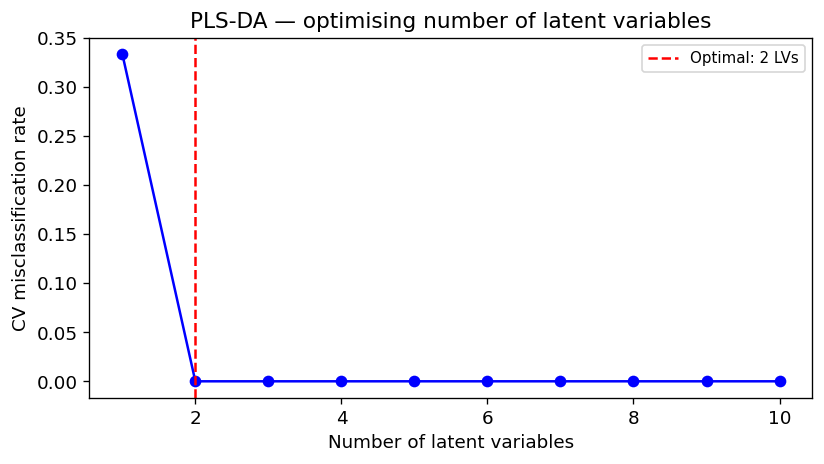

In [9]:
# -------------------------------------------------------------------------
# PLS-DA: optimise number of latent variables by cross-validation
# -------------------------------------------------------------------------

# One-hot encode the class labels: Y_bin[i, k] = 1 if sample i is class k
Y_bin = label_binarize(y, classes=[0, 1, 2])   # shape (45, 3)

max_lv    = 10
cv_errors = []
# Precompute stratified folds from the integer y so that StratifiedKFold
# sees class labels (not a one-hot matrix) for stratification.
cv_splits = list(
    StratifiedKFold(n_splits=15, shuffle=True, random_state=42).split(X, y)
)

for n_lv in range(1, max_lv + 1):
    pls_cv    = PLSRegression(n_components=n_lv, scale=False)
    Y_pred_cv = cross_val_predict(pls_cv, X, Y_bin, cv=cv_splits)
    y_pred_cv = Y_pred_cv.argmax(axis=1)
    cv_errors.append((y_pred_cv != y).mean())

best_n_lv = int(np.argmin(cv_errors)) + 1

print('Cross-validated error rates:')
for n, err in enumerate(cv_errors, 1):
    bar = '█' * int((1 - err) * 20)
    print(f'  {n:2d} LV: {err:.3f} error  ({(1-err)*100:.0f}% correct)  {bar}')
print(f'\nOptimal number of latent variables: {best_n_lv}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, max_lv + 1), cv_errors, 'bo-', markersize=6)
ax.axvline(best_n_lv, color='red', linestyle='--',
           label=f'Optimal: {best_n_lv} LVs')
ax.set_xlabel('Number of latent variables')
ax.set_ylabel('CV misclassification rate')
ax.set_title('PLS-DA — optimising number of latent variables')
ax.legend()
plt.tight_layout()
plt.show()

cv = cv_splits   # alias so subsequent cells can reuse

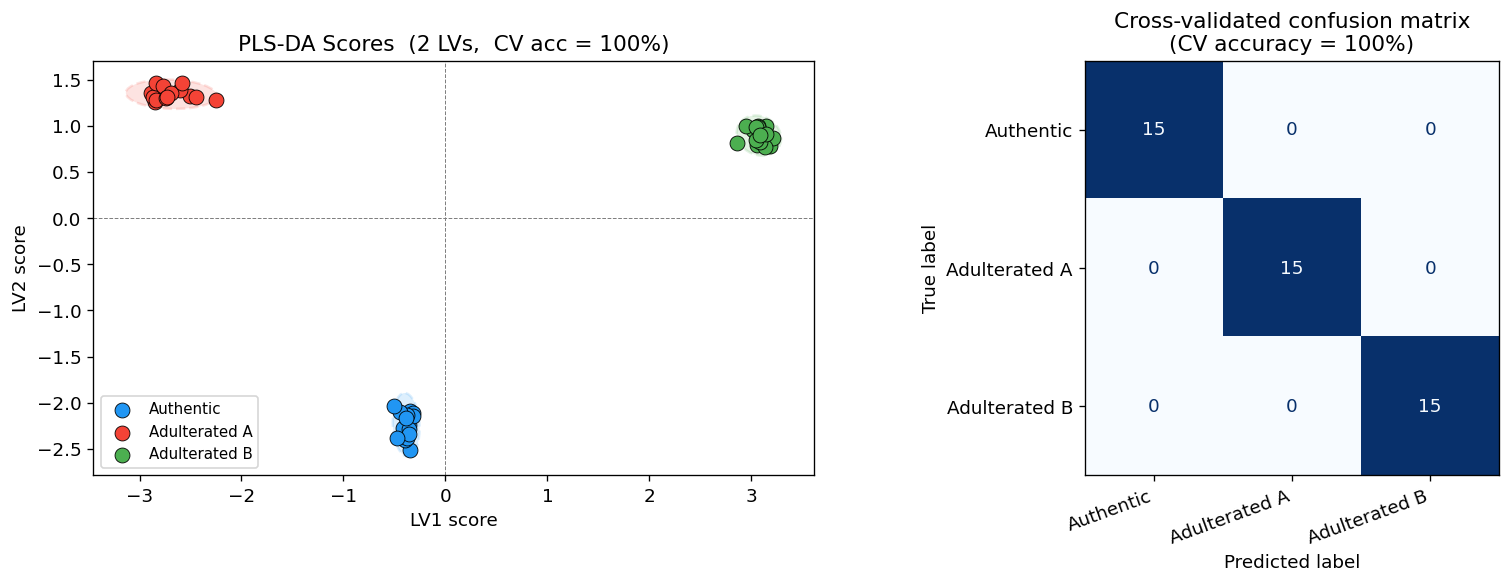

In [10]:
# -------------------------------------------------------------------------
# Fit final PLS-DA with optimal number of LVs
# -------------------------------------------------------------------------

pls = PLSRegression(n_components=best_n_lv, scale=False)
pls.fit(X, Y_bin)

pls_scores = pls.x_scores_   # LV coordinates of each sample

# Cross-validated predictions for the confusion matrix
Y_pred_cv = cross_val_predict(pls, X, Y_bin, cv=cv)
y_pred_cv = Y_pred_cv.argmax(axis=1)
cv_acc    = (y_pred_cv == y).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scores plot
ax = axes[0]
for cls_idx, (cls_name, col) in enumerate(zip(CLASS_NAMES, CLASS_COLOURS)):
    mask = y == cls_idx
    confidence_ellipse(pls_scores[mask, :2], ax, col)
    ax.scatter(pls_scores[mask, 0], pls_scores[mask, 1],
               color=col, edgecolors='k', linewidths=0.5,
               s=80, label=cls_name, zorder=5)
ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--')
ax.set_xlabel('LV1 score')
ax.set_ylabel('LV2 score')
ax.set_title(f'PLS-DA Scores  ({best_n_lv} LVs,  CV acc = {cv_acc:.0f}%)')
ax.legend()

# Cross-validated confusion matrix
ax = axes[1]
cm_matrix = confusion_matrix(y, y_pred_cv)
disp = ConfusionMatrixDisplay(cm_matrix, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Cross-validated confusion matrix\n(CV accuracy = {cv_acc:.0f}%)')
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')

plt.tight_layout()
plt.show()

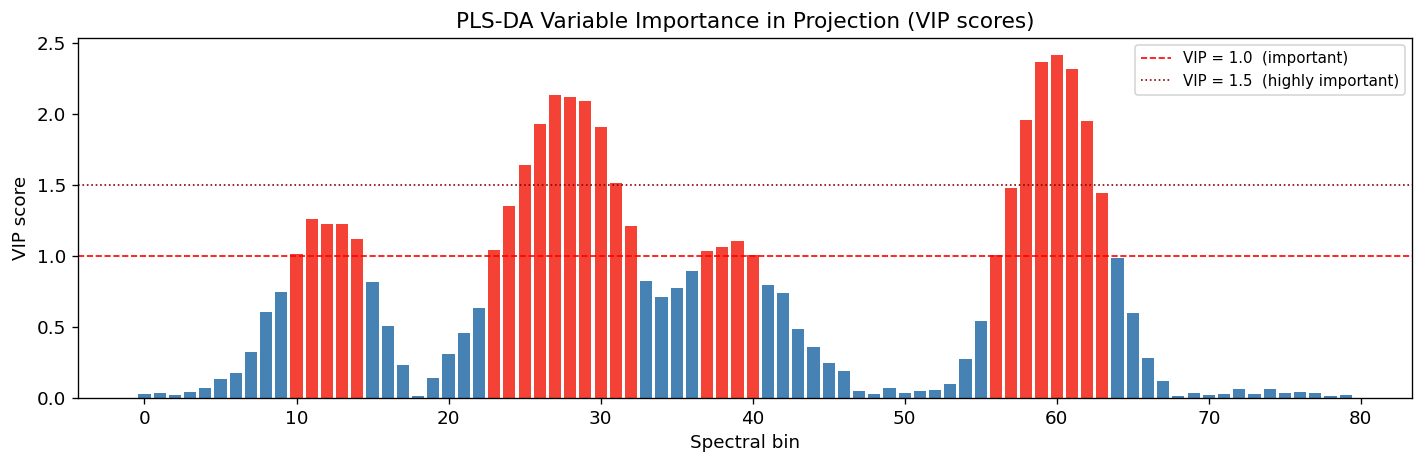

Bins with VIP > 1.0 : [10, 11, 12, 13, 14, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 37, 38, 39, 40, 56, 57, 58, 59, 60, 61, 62, 63]
Simulated marker peaks at bins: 12 (all classes), 28 (Adulterated A), 38 (all classes), 60 (Adulterated B)


In [11]:
# -------------------------------------------------------------------------
# VIP scores  (Variable Importance in Projection)
#
# VIP scores quantify how much each spectral bin contributes to the PLS-DA
# model, summed across all latent variables.
# Rule of thumb: VIP > 1.0 = important; VIP > 1.5 = highly important.
# -------------------------------------------------------------------------


def compute_vip(pls_model):
    '''Compute VIP scores for a fitted sklearn PLSRegression model.'''
    t = pls_model.x_scores_     # X scores   (n_samples, n_lv)
    w = pls_model.x_weights_    # X weights  (n_features, n_lv)
    q = pls_model.y_loadings_   # Y loadings (n_targets,  n_lv)
    p = w.shape[0]
    # SS explained by each LV
    SS       = np.sum(t ** 2, axis=0) * np.sum(q ** 2, axis=0)
    SS_total = SS.sum()
    vip = np.zeros(p)
    for k in range(p):
        w_norm = (w[k, :] / np.linalg.norm(w, axis=0)) ** 2
        vip[k] = np.sqrt(p * np.dot(SS, w_norm) / SS_total)
    return vip


vip = compute_vip(pls)

fig, ax = plt.subplots(figsize=(12, 4))
colours_vip = ['#F44336' if v > 1.0 else 'steelblue' for v in vip]
ax.bar(x, vip, color=colours_vip, edgecolor='none')
ax.axhline(1.0, color='red',     linestyle='--', linewidth=1.0,
           label='VIP = 1.0  (important)')
ax.axhline(1.5, color='darkred', linestyle=':',  linewidth=1.0,
           label='VIP = 1.5  (highly important)')
ax.set_xlabel('Spectral bin')
ax.set_ylabel('VIP score')
ax.set_title('PLS-DA Variable Importance in Projection (VIP scores)')
ax.legend()
plt.tight_layout()
plt.show()

important = np.where(vip > 1.0)[0]
print(f'Bins with VIP > 1.0 : {important.tolist()}')
print(f'Simulated marker peaks at bins: 12 (all classes), 28 (Adulterated A),'
      f' 38 (all classes), 60 (Adulterated B)')

## 6 · Orthogonal PLS-DA (OPLS-DA)

### Why OPLS-DA?

PLS-DA maximises covariance between spectra and class labels, but it mixes
two types of variation:

1. **Predictive variation** — spectral differences that correlate with the
   class label (what we want)
2. **Orthogonal variation** — real spectral variation *not* related to the
   class label (concentration effects, instrument drift, etc.)

OPLS-DA (Trygg & Wold, 2002) explicitly separates these two types.
The result is a simpler, more interpretable model with:
- One **predictive component** (the discriminant axis)
- One or more **orthogonal components** (capturing irrelevant variation)

### When to use OPLS-DA

- **Pairwise comparison**: OPLS-DA is designed for two-class problems.
  For three or more classes, run multiple pairwise comparisons.
- **After PLS-DA**: use OPLS-DA to confirm and refine a PLS-DA finding, not
  to replace cross-validation.

### The S-plot

The S-plot plots, for each spectral bin, its **covariance** with the
predictive scores (x-axis) against its **correlation** with those scores
(y-axis). Variables in the top-right or bottom-left corners are both
important *and* reliable — the ideal biomarker candidates.

Classes: 'Authentic' (n=15) vs 'Adulterated A' (n=15)
Predictive component: R2Y = 99.7%
Orthogonal component: 24.2% of residual X variance


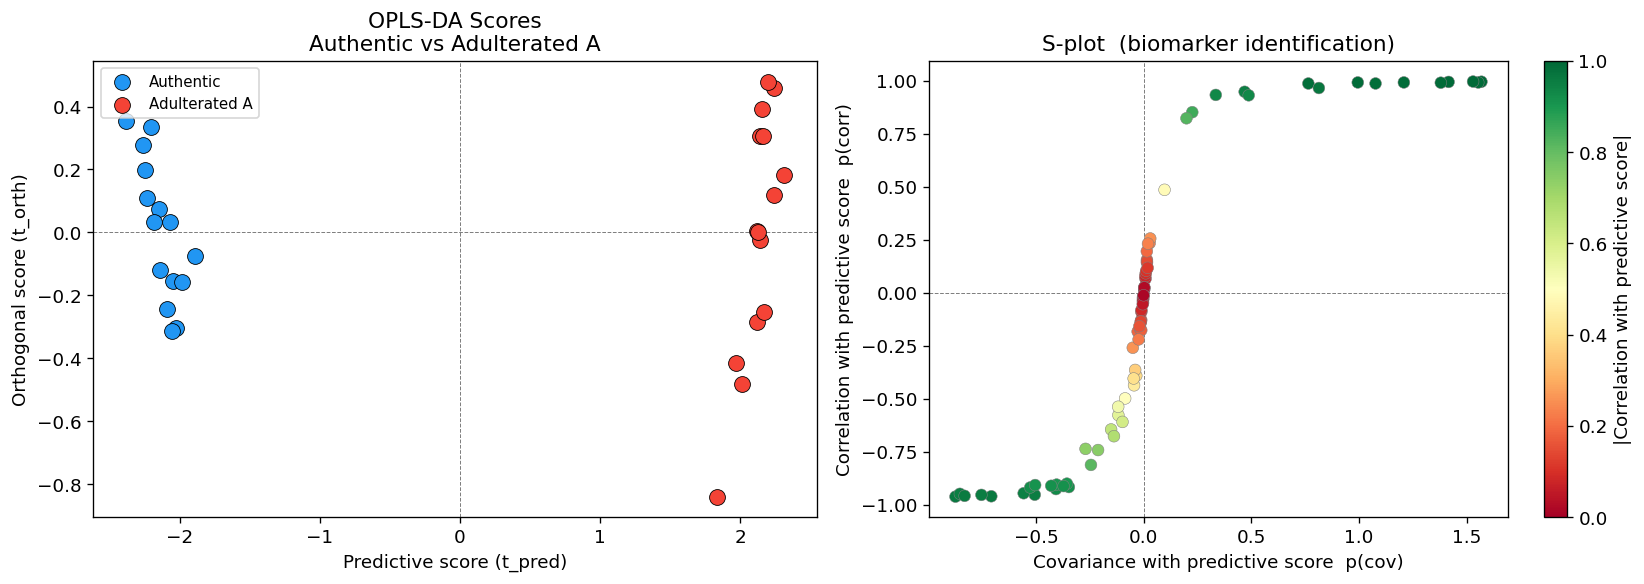

In [12]:
# -------------------------------------------------------------------------
# OPLS-DA: pairwise comparison  (Authentic  vs  Adulterated A)
#
# Implementation using the deflation approach:
#   1. Fit PLS(1) on the binary y  ->  predictive component
#   2. Remove (deflate) the predictive component from X
#   3. PCA on the residual X  ->  orthogonal component
# -------------------------------------------------------------------------

CLS_A, CLS_B = 0, 1    # Authentic vs Adulterated A
mask_ab  = (y == CLS_A) | (y == CLS_B)
X_ab     = X[mask_ab]
y_ab     = y[mask_ab]
y_ab_bin = (y_ab == CLS_B).astype(float).reshape(-1, 1)   # 0/1 vector

print(f"Classes: '{CLASS_NAMES[CLS_A]}' (n={(y_ab==CLS_A).sum()}) "
      f"vs '{CLASS_NAMES[CLS_B]}' (n={(y_ab==CLS_B).sum()})")

# Step 1: PLS(1) -> predictive component
pls1 = PLSRegression(n_components=1, scale=False)
pls1.fit(X_ab, y_ab_bin)
t_pred = pls1.x_scores_[:, 0]   # predictive scores
p_pred = pls1.x_loadings_[:, 0] # predictive X-loadings

# Step 2: deflate X
X_orth = X_ab - np.outer(t_pred, p_pred)

# Step 3: PCA on residual -> orthogonal component
pca_orth = PCA(n_components=1)
t_orth   = pca_orth.fit_transform(X_orth)[:, 0]

print(f'Predictive component: R2Y = {pls1.score(X_ab, y_ab_bin)*100:.1f}%')
print(f'Orthogonal component: {pca_orth.explained_variance_ratio_[0]*100:.1f}%'
      f' of residual X variance')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OPLS-DA scores plot
ax = axes[0]
for cls_val, col, name in zip([CLS_A, CLS_B],
                               [CLASS_COLOURS[CLS_A], CLASS_COLOURS[CLS_B]],
                               [CLASS_NAMES[CLS_A],  CLASS_NAMES[CLS_B]]):
    m = y_ab == cls_val
    ax.scatter(t_pred[m], t_orth[m],
               color=col, edgecolors='k', linewidths=0.5, s=90,
               label=name, zorder=5)
ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--')
ax.set_xlabel('Predictive score (t_pred)')
ax.set_ylabel('Orthogonal score (t_orth)')
ax.set_title(f'OPLS-DA Scores\n{CLASS_NAMES[CLS_A]} vs {CLASS_NAMES[CLS_B]}')
ax.legend()

# S-plot
ax = axes[1]
cov_vals  = np.array([np.cov(X_ab[:, k], t_pred)[0, 1] for k in range(N_VARS)])
corr_vals = np.array([np.corrcoef(X_ab[:, k], t_pred)[0, 1] for k in range(N_VARS)])
sc = ax.scatter(cov_vals, corr_vals, c=np.abs(corr_vals),
                cmap='RdYlGn', vmin=0, vmax=1,
                edgecolors='grey', linewidths=0.3, s=50, zorder=5)
plt.colorbar(sc, ax=ax, label='|Correlation with predictive score|')
ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--')
ax.set_xlabel('Covariance with predictive score  p(cov)')
ax.set_ylabel('Correlation with predictive score  p(corr)')
ax.set_title('S-plot  (biomarker identification)')

plt.tight_layout()
plt.show()

## 7 · Permutation Testing (Model Validation)

### The problem with supervised models

Any supervised model, if trained and tested on the same data, will appear to
perform well — even on random noise. Cross-validation helps, but a single
CV accuracy is still a single number. Is it large enough to be convincing?

### Permutation testing

**Idea**: repeatedly shuffle the class labels at random and refit the model.
If the model detects *genuine* class structure, the CV accuracy on permuted
data should be much lower than on the real data.

**Null hypothesis (H₀)**: the class labels are unrelated to the spectral data.

**p-value**: the fraction of permutations that yield a CV accuracy as high as
or higher than the real accuracy. p < 0.05 allows rejection of H₀.

Typically 999 permutations are used; we use 199 here for speed.

Real CV accuracy  : 100.0%
Mean permuted acc : 28.9% +/- 13.1%
p-value           : 0.0000  (SIGNIFICANT)


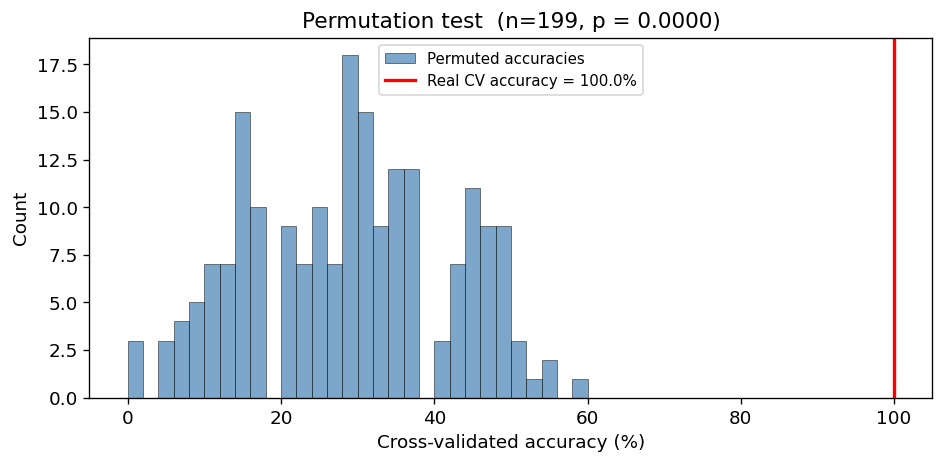

In [13]:
# -------------------------------------------------------------------------
# Permutation test for the PLS-DA model  (all three classes)
# -------------------------------------------------------------------------

N_PERMS  = 199
real_acc = (y_pred_cv == y).mean()   # from the cross-validation above
perm_accs = []

for _ in range(N_PERMS):
    y_perm   = np.random.permutation(y)
    Y_perm   = label_binarize(y_perm, classes=[0, 1, 2])
    pls_p    = PLSRegression(n_components=best_n_lv, scale=False)
    Y_pred_p = cross_val_predict(pls_p, X, Y_perm, cv=cv)
    y_pred_p = Y_pred_p.argmax(axis=1)
    perm_accs.append((y_pred_p == y_perm).mean())

perm_accs = np.array(perm_accs)
p_value   = (perm_accs >= real_acc).mean()

print(f'Real CV accuracy  : {real_acc*100:.1f}%')
print(f'Mean permuted acc : {perm_accs.mean()*100:.1f}% +/- {perm_accs.std()*100:.1f}%')
sig = 'SIGNIFICANT' if p_value < 0.05 else 'not significant'
print(f'p-value           : {p_value:.4f}  ({sig})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_accs * 100, bins=30, color='steelblue',
        edgecolor='k', linewidth=0.4, alpha=0.7, label='Permuted accuracies')
ax.axvline(real_acc * 100, color='red', linewidth=2,
           label=f'Real CV accuracy = {real_acc*100:.1f}%')
ax.set_xlabel('Cross-validated accuracy (%)')
ax.set_ylabel('Count')
ax.set_title(f'Permutation test  (n={N_PERMS}, p = {p_value:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

## 8 · Summary and Decision Guide

### What each method contributes

| Method | Type | Key output | What to report |
|--------|------|-----------|----------------|
| **PCA** | Unsupervised | Scores plot, loadings, scree plot | % variance explained; discriminating bins; class clustering |
| **HCA** | Unsupervised | Dendrogram | Linkage method; whether true classes cluster together |
| **PLS-DA** | Supervised | CV accuracy, confusion matrix, VIP | Number of LVs; CV accuracy; VIP > 1 bins |
| **OPLS-DA** | Supervised | S-plot, permutation p-value | p-value; predictive R²Y; S-plot biomarker bins |

### Decision guide

```
Does the PCA scores plot show class separation?
├── YES → PCA is sufficient for an overview.
│         Use loadings to identify discriminating spectral regions.
└── NO  → Either (a) differences are subtle → try PLS-DA,
              or (b) other variation dominates → review preprocessing.

Is CV accuracy in PLS-DA high (and permutation test significant)?
├── YES → Report VIP scores for biomarker identification.
│         Use OPLS-DA for pairwise comparisons and the S-plot.
└── NO  → Review preprocessing; consider more samples.
```

### Key principles

- **Always visualise first** — look at raw spectra before any multivariate analysis
- **Mean-centre before PCA or PLS** — this is mandatory
- **Cross-validate supervised models** — never report calibration accuracy alone
- **PCA is exploratory** — it does not test hypotheses
- **VIP > 1 + S-plot** — use together to identify confident biomarker bins
- **Permutation test** — p < 0.05 confirms genuine class structure, not overfitting

## References

- Trygg J, Wold S. Orthogonal projections to latent structures (O-PLS).
  *J Chemometr*. 2002;16(3):119–128. [doi:10.1002/cem.695](https://doi.org/10.1002/cem.695)

- Wold S, Sjöström M, Eriksson L. PLS-regression: a basic tool of chemometrics.
  *Chemometr Intell Lab Syst*. 2001;58(2):109–130.
  [doi:10.1016/S0169-7439(01)00155-1](https://doi.org/10.1016/S0169-7439(01)00155-1)

- Jolliffe IT. *Principal Component Analysis*. 2nd ed. Springer; 2002.

- Eriksson L, Byrne T, Johansson E, Trygg J, Vikström C.
  *Multi- and Megavariate Data Analysis Basic Principles and Applications*. 3rd ed.
  MKS Umetrics; 2013.

---

**Contact:** Gunter Kuhnle — g.g.kuhnle@reading.ac.uk  
Department of Food and Nutritional Sciences, University of Reading